###Exercise 4: NumPy Array Operations

In [79]:
"""
Exercise 4: NumPy Array Operations
"""
import numpy as np

# Task 1: Creating a 5x5 matrix where border elements are 1 and interior is 0
mat1 = np.ones((5,5))
mat1[1:4, 1:4] = 0
print("Matrix: " , mat1)


# Task 2: Normalizing a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

# Normalizing each column to have mean=0 and std=1
normalized_array = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print("Normalized array: ", normalized_array)


# Task 3: Implementing linear regression solution using normal equation
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Calculating theta_hat using the normal equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
# Printing the estimated coefficients and comparing with true_theta
print("True theta: ", true_theta)
print("Theta hat: ", theta_hat)

print("Since theta and theta hat vary by +/- 0.02, we can say that the estimation is quite accurate")

Matrix:  [[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
Normalized array:  [[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e

###Exercise 5: Pandas Data Analysis

In [40]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration
# Displaying basic information about the dataset
print("Column names: \n", df.columns)
print("Data types: \n", df.dtypes)
print("First 5 rows of the dataset: \n", df.head(5))
print("Last 5 rows of the dataset: \n", df.tail(5))
print("Statistical summary of the dataset: \n", df.describe())
print("Shape of the dataset: \n", df.shape)

# Identifying and counting missing values
print(df.isnull().sum())

# Filling missing exam_score with the mean score for the student's major
df['exam_score'] = df['exam_score'].fillna(df['exam_score'].mean())

# Filling missing hours_studied with the median for the student's year
df['hours_studied'] = df['hours_studied'].fillna(df['hours_studied'].mean())

print(df.isnull().sum())


# Task 2: Analysis
# Calculating and displaying the average exam_score by major
average_score = df.groupby('major')['exam_score'].mean()
print("Average score by major: \n", average_score)

# Finding the major with the highest average exam_score
highest_average = average_score.idxmax()
print("Major with the highest exam average: \n", highest_average)

# Calculating the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print("Correlation between hours studied and exam score: \n", correlation)

# Creating a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
conditions = [(df['exam_score'] > 90), ((df['exam_score'] >= 80) & (df['exam_score'] <= 90)), ((df['exam_score'] >= 70) & (df['exam_score'] < 80))]
grade = ['Excellent', 'Good', 'Average']
df['performance'] = np.select(conditions, grade, default = 'Needs Improvement')
print(df)


# Task 3: Advanced Analysis
# Calculating, for each major and year combination, the:
#       - Number of students
#       - Average exam score
#       - Average hours studied
sorted = df.groupby(['major', 'year']).agg({'student_id' : 'count', 'exam_score' : 'mean', 'hours_studied' : 'mean'})
print("Number of students, average exam score and average hours studied for each major and year combination")
print(sorted)

# Identifying top 5 students based on exam_score (handle ties appropriately)
top_students = df.nlargest(5, 'exam_score')
print(top_students)

# Creating a pivot table showing average exam_score by major (rows) and year (columns)
pivot_table = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)
print(pivot_table)

Column names: 
 Index(['student_id', 'major', 'year', 'exam_score', 'assignments_completed',
       'hours_studied'],
      dtype='object')
Data types: 
 student_id                 int64
major                     object
year                       int64
exam_score               float64
assignments_completed      int64
hours_studied            float64
dtype: object
First 5 rows of the dataset: 
    student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics     4   93.657745                      6      15.287370
Last 5 rows of the dataset: 
      student_id    major  year  exam_score  assignments_completed  \
195        1195     Math     4

###Exercise 6: Data Visualization

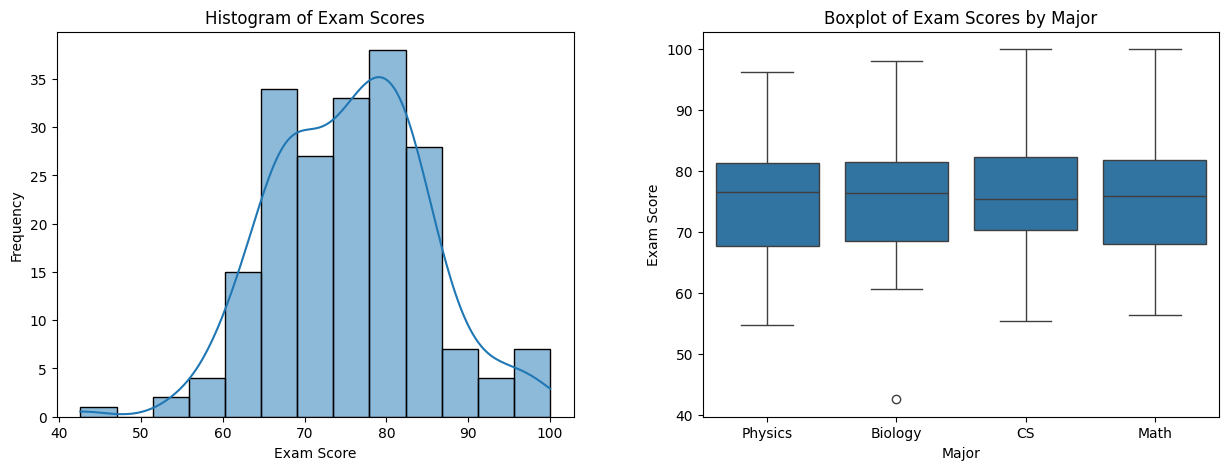

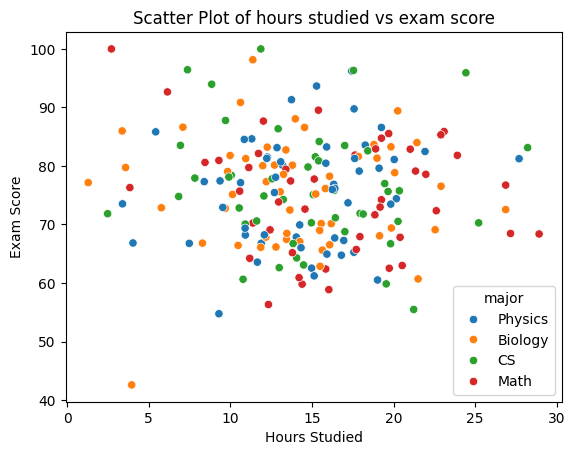

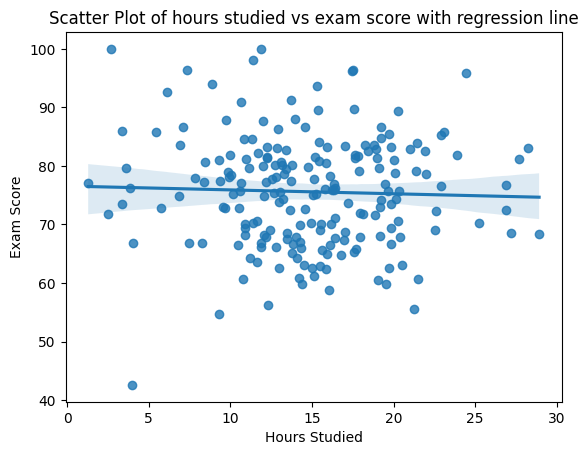

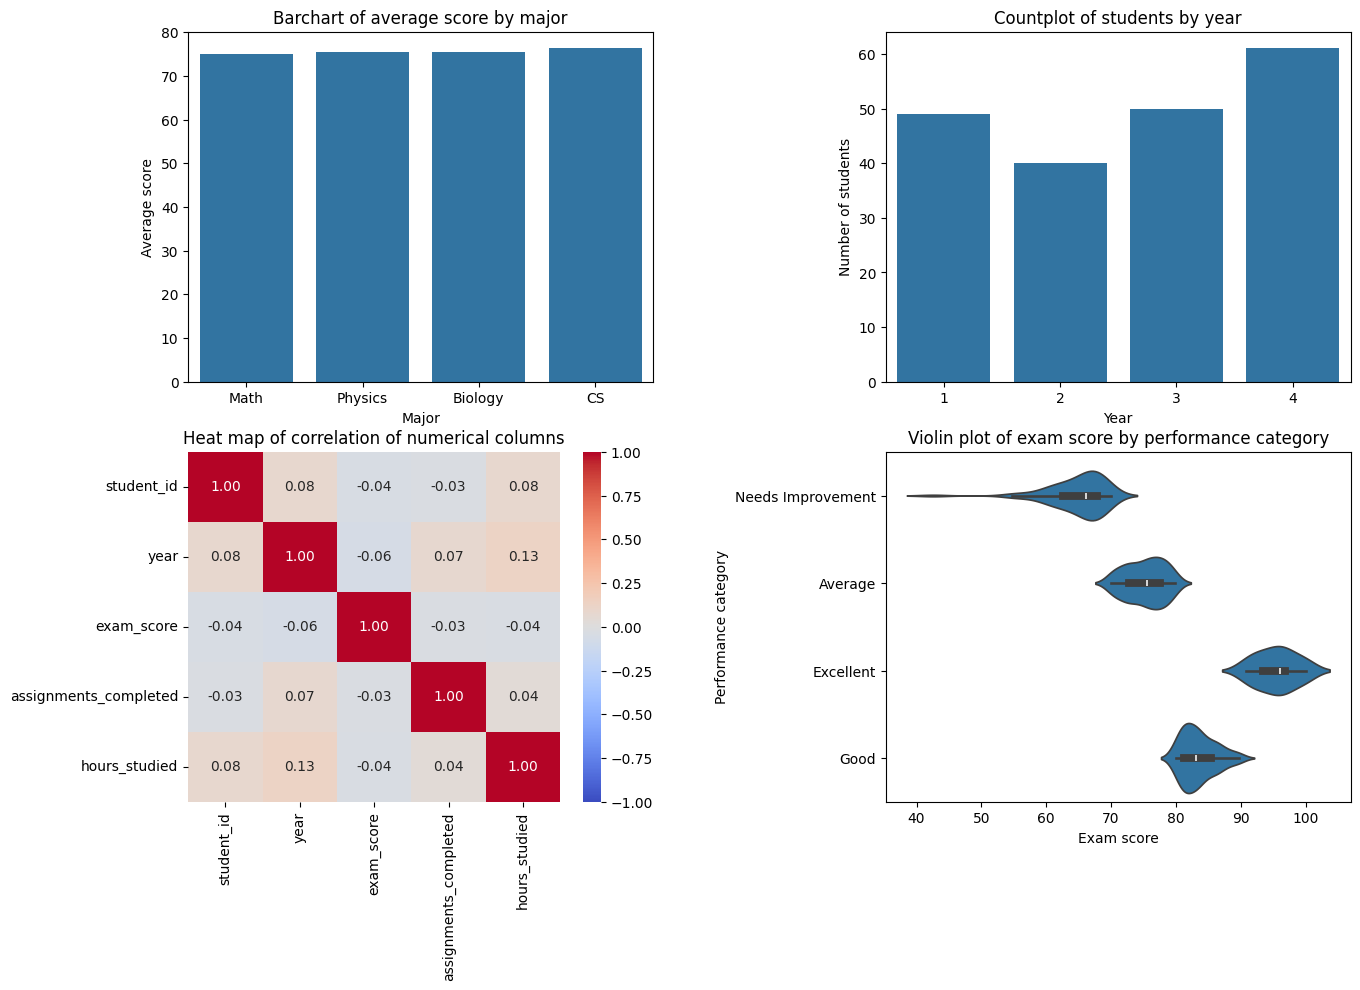

In [84]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

conditions = [(df['exam_score'] > 90), ((df['exam_score'] >= 80) & (df['exam_score'] <= 90)), ((df['exam_score'] >= 70) & (df['exam_score'] < 80))]
grade = ['Excellent', 'Good', 'Average']
df['performance'] = np.select(conditions, grade, default = 'Needs Improvement')

# Task 1: Distribution Visualization
# Creating a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15,5))

sns.histplot(data=df, x='exam_score', kde=True, ax=ax1)
ax1.set_title('Histogram of Exam Scores')
ax1.set_xlabel('Exam Score')
ax1.set_ylabel('Frequency')

sns.boxplot(data=df, x='major', y='exam_score', ax=ax2)
ax2.set_title('Boxplot of Exam Scores by Major')
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Score')
plt.subplots_adjust(wspace=0.25)
plt.show()


# Task 2: Relationship Visualization
# Creating a scatter plot of hours_studied vs exam_score
# Coloring points by major
sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major')
plt.title("Scatter Plot of hours studied vs exam score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

# Adding a regression line
sns.regplot(data = df, x = 'hours_studied', y = 'exam_score', scatter = True)
plt.title("Scatter Plot of hours studied vs exam score with regression line")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()


# Task 3: Advanced Dashboard (9 points)
# Creating a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
average_score = df.groupby('major')['exam_score'].mean().sort_values()
fig, axs = plt.subplots(2, 2, figsize = (15,10))

sns.barplot(x = average_score.index, y = average_score.values ,ax=axs[0,0])
axs[0, 0].set_title('Barchart of average score by major')
axs[0, 0].set_ylabel('Average score')
axs[0, 0].set_xlabel('Major')
sns.countplot(data=df, x = 'year', ax=axs[0, 1])
axs[0, 1].set_title('Countplot of students by year')
axs[0, 1].set_ylabel('Number of students')
axs[0, 1].set_xlabel('Year')
sns.heatmap(df.corr(numeric_only=True), annot = True, fmt = '.2f', cmap = 'coolwarm', ax=axs[1, 0],vmin = -1, vmax = 1)
axs[1, 0].set_title('Heat map of correlation of numerical columns')
sns.violinplot(data=df, x="exam_score", y="performance", ax=axs[1, 1])
axs[1, 1].set_title('Violin plot of exam score by performance category')
axs[1, 1].set_ylabel('Performance category')
axs[1, 1].set_xlabel('Exam score')
plt.subplots_adjust(wspace=0.5)



###Exercise 7: Integration Challenge

Customer lifeftime value: 
 0       937.397271
1       370.085023
2       418.424348
3       477.171887
4      1097.651683
          ...     
495     750.052567
496     408.682977
497     276.305018
498    1149.667906
499     780.543489
Name: CLV, Length: 500, dtype: float64
Customers grouped by ages: 
 0      51-70
1      51-70
2      36-50
3      26-35
4      51-70
       ...  
495    51-70
496    36-50
497    51-70
498    51-70
499      NaN
Name: age_group, Length: 500, dtype: category
Categories (4, object): ['18-25' < '26-35' < '36-50' < '51-70']
Number of customers grouped by age groups: 
 age_group
18-25     69
26-35     73
36-50    160
51-70    186
dtype: int64
Average income of customers grouped by age groups: 
 age_group
18-25    51805.879852
26-35    48747.148046
36-50    48516.895668
51-70    50713.163384
Name: income, dtype: float64
Average CLV of customers grouped by age groups: 
 age_group
18-25    704.492597
26-35    747.738562
36-50    732.796612
51-70    762.693498
Na

/tmp/ipykernel_14154/3607729505.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_number = customers.groupby('age_group').size()
/tmp/ipykernel_14154/3607729505.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_income = customers.groupby('age_group')['income'].mean()
/tmp/ipykernel_14154/3607729505.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_CLV = customers.groupby('age_group')['CL

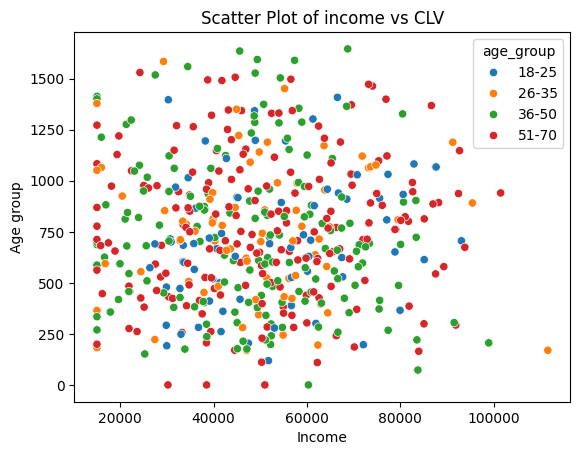

/tmp/ipykernel_14154/3607729505.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customers, x = "age_group", y = 'CLV', palette="pastel", estimator = 'mean')


Text(0.5, 1.0, 'Correlation heatmap')

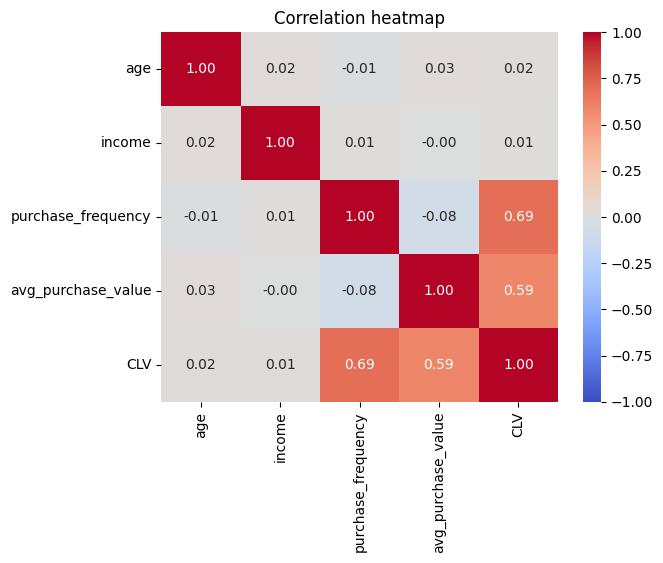

In [78]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Calculating customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
churn_risk = 1 - (purchase_freq / purchase_freq.max())
customers['CLV'] = purchase_freq * avg_purchase_value * (1 + churn_risk)
print("Customer lifeftime value: \n", customers['CLV'])

# Creating age groups: 18-25, 26-35, 36-50, 51-70
age_grouping = pd.cut(customers['age'], bins=[18, 25, 35, 50, 70], labels=['18-25', '26-35', '36-50', '51-70'])
customers['age_group'] = age_grouping
print("Customers grouped by ages: \n", customers['age_group'])

# Calculating, for each age group, the:
#       - Number of customers
customer_number = customers.groupby('age_group').size()
print("Number of customers grouped by age groups: \n", customer_number)
#       - Average income
average_income = customers.groupby('age_group')['income'].mean()
print("Average income of customers grouped by age groups: \n", average_income)
#       - Average CLV
average_CLV = customers.groupby('age_group')['CLV'].mean()
print("Average CLV of customers grouped by age groups: \n", average_CLV)
#       - Total CLV
total_CLV = customers.groupby('age_group')['CLV'].sum()
print("Total CLV of customers grouped by age groups: \n", total_CLV)

# Identifying the top 10% of customers by CLV
customers_sorted = customers.sort_values('CLV', ascending=False)
top_ten = int(len(customers)/10)
top_tenCLV = customers_sorted.head(top_ten)
print("Top 10% of customers by CLV: \n", top_tenCLV)

# Creating visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
sns.scatterplot(data=customers, x='income', y='CLV', hue='age_group')
plt.title("Scatter Plot of income vs CLV")
plt.xlabel("Income")
plt.ylabel("Age group")
plt.show()

#       2. Bar chart of average CLV by age group
sns.barplot(data=customers, x = "age_group", y = 'CLV', palette="pastel", estimator = 'mean')
plt.title('Barchart of average CLV by age group')
plt.ylabel('Average CLV')
plt.xlabel('Age group')

#       3. Correlation heatmap
correlation = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr()
sns.heatmap(correlation, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Correlation heatmap')

###Brief analysis of exercise 7

From the data above, most of their customers fall within the age group 51-70,  meaning a majority of their customers are aged. The aged also show a high total CLV as compared to the other age groups. However, this could be as a result of the large number of the aged customer base. Although they are still leading when their average CLVs are compared, there could be a hidden factor contributing to it and so it is not safe to make any conclusions yet. I would suggest the company focus on the older custoomers more but still conduct further research to prevent using resources in the wrong direction.

